# RL training for iterated prisoner's dilemma

In [8]:
# Imports
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [115]:
# Print cwd
print(os.getcwd())
# Run using Termial from Project Directory with the command to be able to import from src
# jupyter notebook src/utils/RLTraining.ipynb --notebook-dir /home/keepgpu/PrisionersDilemma/PrisonersDilemma

/home/keepgpu/PrisionersDilemma/PrisonersDilemma


In [10]:
# Verify that the GPU is available
assert torch.cuda.is_available()

# Define the device
device = torch.device("cuda")

# Set the random seed for reproducibility
torch.manual_seed(0)

In [96]:
# Get game parameters and other constants
payoff_matrix = {
    "00": [3, 3],
    "01": [0, 5],
    "10": [5, 0],
    "11": [1, 1]
}

#              [C, D]
option_space = [0, 1]

In [28]:
# Define the state of the game
"""
We use the following features to define the state of the game:
- The previous action of the agent
- The previous action of the opponent
- The previous reward of the agent
- The previous reward of the opponent
- The average reward of the agent
- The average reward of the opponent
- The number of rounds played
- The number of rounds played since the last cooperation
"""

class QState:
    def __init__(self):
        self.agent_action = None
        self.opponent_action = None
        self.agent_reward = None
        self.opponent_reward = None
        self.agent_avg_reward = None
        self.opponent_avg_reward = None
        self.rounds_played = 0
        self.rounds_since_last_cooperation = 0

    def update(self, agent_action, opponent_action, agent_reward, opponent_reward):
        self.agent_action = agent_action
        self.opponent_action = opponent_action
        self.agent_reward = agent_reward
        self.opponent_reward = opponent_reward
        self.agent_avg_reward = (self.agent_avg_reward * self.rounds_played + agent_reward) / (self.rounds_played + 1)
        self.opponent_avg_reward = (self.opponent_avg_reward * self.rounds_played + opponent_reward) / (self.rounds_played + 1)
        self.rounds_played += 1
        if agent_action == 0:
            self.rounds_since_last_cooperation = 0
        else:
            self.rounds_since_last_cooperation += 1
    
    def reset(self):
        self.agent_action = None
        self.opponent_action = None
        self.agent_reward = None
        self.opponent_reward = None
        self.agent_avg_reward = None
        self.opponent_avg_reward = None
        self.rounds_played = 0
        self.rounds_since_last_cooperation = 0
        
    def get_state(self):
        return torch.tensor([
            self.agent_action,
            self.opponent_action,
            self.agent_reward,
            self.opponent_reward,
            self.agent_avg_reward,
            self.opponent_avg_reward,
            self.rounds_played,
            self.rounds_since_last_cooperation
        ]).to(device).float()

In [29]:
# Create a Q-Learning agent
# The agent will be a neural network that takes the current state as input and outputs the Q-values for each action
# Make sure that this can run on the GPU
class QLearningAgent(nn.Module):
    def __init__(self, input_size, output_size):
        super(QLearningAgent, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [72]:
# Create the agent
agent = QLearningAgent(8, 2).to(device)

# Define the optimizer
optimizer = optim.Adam(agent.parameters(), lr=0.001)

# Define the loss function
loss_fn = nn.L1Loss()

In [91]:
# Define the epsilon-greedy policy
def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        print("Random")
        choice = np.random.choice(option_space)
    else:
        with torch.no_grad():
            q_values = agent(state)
            choice = torch.argmax(q_values).item()
    if choice == 0:
        print("Play C")
        return [1, 0]
    else:
        print("Play D")
        return [0, 1]

In [92]:
# Test the epsilon-greedy policy

# Set a test state
state = QState()
state.agent_action = 1
state.opponent_action = 0
state.agent_reward = 1
state.opponent_reward = 3
state.agent_avg_reward = 2.56156
state.opponent_avg_reward = 3.56483
state.rounds_played = 182
state.rounds_since_last_cooperation = 15

# Set the epsilon
epsilon = 0.1

# Test the policy
print(epsilon_greedy_policy(state.get_state(), epsilon))

Play D
[0, 1]


In [93]:
# Update the Q-values using Q-Learning

def update_q_values(state, action, reward, next_state, discount_factor, learning_rate):
    q_values = agent(state)
    next_q_values = agent(next_state)
    next_q_value = torch.max(next_q_values).item()
    target = torch.tensor(reward + discount_factor * next_q_value).to(device).float()
    q_value = torch.tensor(q_values[action], requires_grad=True).to(device).float()
    loss = loss_fn(q_value, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [114]:
# Q-Learning training loop
# Define the training parameters
num_episodes = 100
discount_factor = 0.99
learning_rate = 0.001
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = (epsilon_end - epsilon_start) / num_episodes

# Define the training loop
for episode in range(num_episodes):
    state = QState()
    state.agent_action = 0
    state.opponent_action = 0
    state.agent_reward = 0
    state.opponent_reward = 0
    state.agent_avg_reward = 0
    state.opponent_avg_reward = 0
    state.rounds_played = 0
    state.rounds_since_last_cooperation = 0
    epsilon = epsilon_end + epsilon_decay * np.exp(-episode / num_episodes)
    while True:
        agent_actions = epsilon_greedy_policy(state.get_state(), epsilon)
        agent_action = np.argmax(agent_actions)
        opponent_action = np.random.choice(option_space)
        rewards = payoff_matrix[str(agent_action) + str(opponent_action)]
        agent_reward = rewards[0]
        opponent_reward = rewards[1]
        state.update(agent_action, opponent_action, agent_reward, opponent_reward)
        next_state = state.get_state()
        loss = update_q_values(state.get_state(), agent_action, agent_reward, next_state, discount_factor, learning_rate)
        if state.rounds_played >= 100:
            break
    state.reset()

Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D


/tmp/ipykernel_5515/3779393259.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_value = torch.tensor(q_values[action], requires_grad=True).to(device).float()


Play D
Play D
Play D
Play D
Random
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Random
Play C
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play C
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D

In [102]:
print("State:")
print(state.get_state())
print("Prediction:")
print(agent.forward(state.get_state()).argmax().item())

State:
tensor([ 1.0000,  0.0000,  5.0000,  0.0000,  2.7432,  0.9865, 74.0000, 64.0000],
       device='cuda:0')
Prediction:
1


Play C
Play D
Play D
Play D
Play D
Play C
Play D
Play D
Play D
Play C
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D
Play D


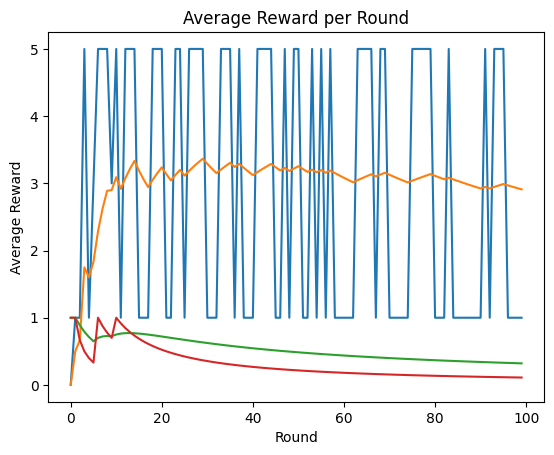

In [108]:
# Test the agent for 100 rounds and plot the results (avg. reward, avg. cooperation rate)
rewards = []
avg_rewards = []
cooperation_rates = []
avg_cooperation_rates = []
actions = []

state = QState()
state.agent_action = 0
state.opponent_action = 0
state.agent_reward = 0
state.opponent_reward = 0
state.agent_avg_reward = 0
state.opponent_avg_reward = 0
state.rounds_played = 0
state.rounds_since_last_cooperation = 0

for _ in range(100):
    agent_actions = epsilon_greedy_policy(state.get_state(), 0.0)
    agent_action = np.argmax(agent_actions)
    actions.append(agent_action)
    opponent_action = np.random.choice(option_space)
    rewards.append(payoff_matrix[str(agent_action) + str(opponent_action)][0])
    avg_rewards.append(sum(rewards) / len(rewards))
    cooperation_rates.append(1 - state.rounds_since_last_cooperation / (state.rounds_played + 1))
    avg_cooperation_rates.append(sum(cooperation_rates) / len(cooperation_rates))
    state.update(agent_action, opponent_action, rewards[-1], 0)
    
# PLot the average rewards
plt.plot(rewards)
plt.plot(avg_rewards)
plt.plot(avg_cooperation_rates)
plt.plot(cooperation_rates)
plt.xlabel("Round")
plt.ylabel("Average Reward")
plt.title("Average Reward per Round")
plt.show()

In [113]:
print("C plays:", sum([1 for action in actions if action == 0]), "of", len(actions))

C plays: 3 of 100
